<a href="https://colab.research.google.com/github/7amokarim/breast-cancer-detection-system/blob/main/cnn_classication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

dataset_path = "/content/drive/MyDrive/breast ultrasound images dataset/Dataset_BUSI_with_GT"

print(os.listdir(dataset_path))

['malignant', 'normal', 'benign']


In [12]:
import cv2
import numpy as np
import os

IMG_SIZE = 224

X = []
y = []

dataset_path = "/content/drive/MyDrive/breast ultrasound images dataset/Dataset_BUSI_with_GT"

for category in ["normal", "benign", "malignant"]:
    path = os.path.join(dataset_path, category)

    for file in os.listdir(path):

        file_lower = file.lower()

        # ❗ امنع أي ماسك بأي شكل
        if "mask" in file_lower:
            continue

        if not file_lower.endswith(".png"):
            continue

        img_path = os.path.join(path, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)

        # label
        if category == "normal":
            y.append(0)
        else:
            y.append(1)

X = np.array(X) / 255.0
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (780, 224, 224, 3)
y shape: (780,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

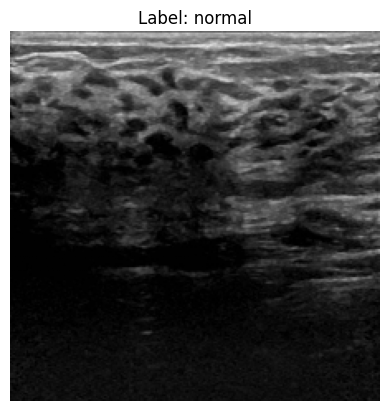

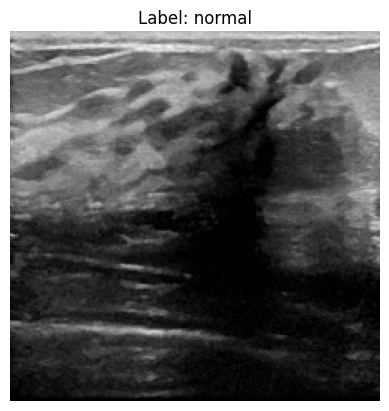

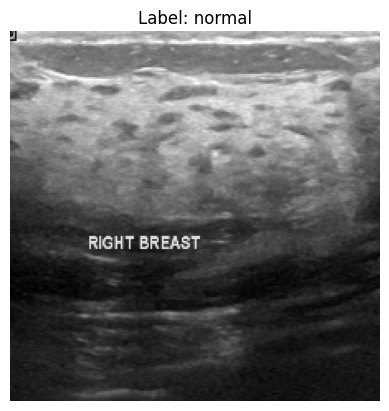

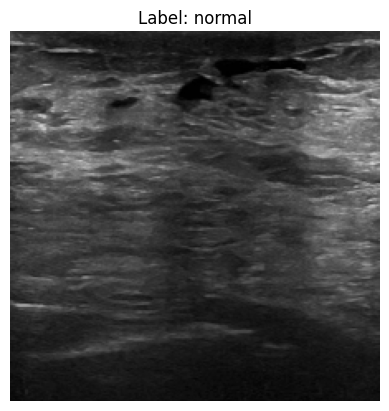

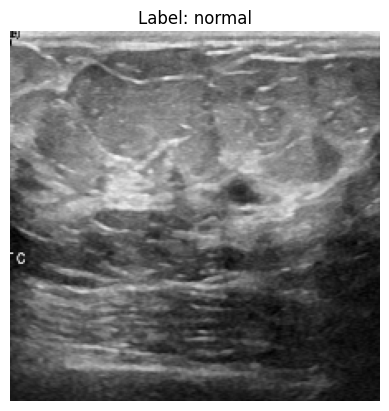

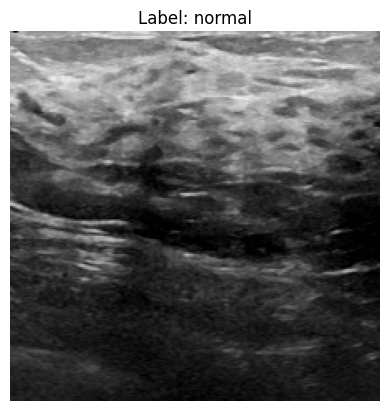

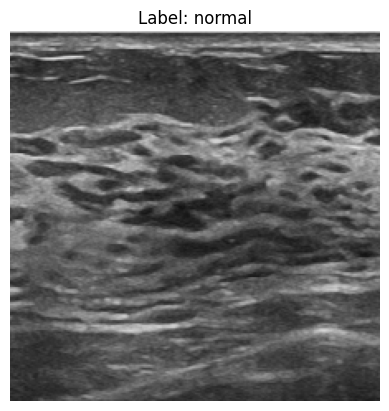

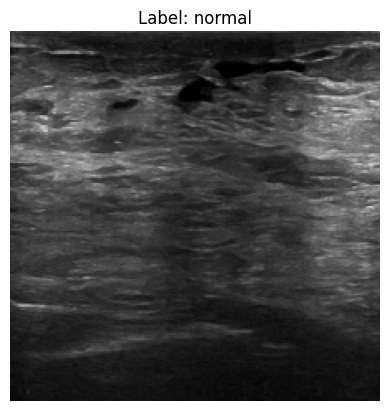

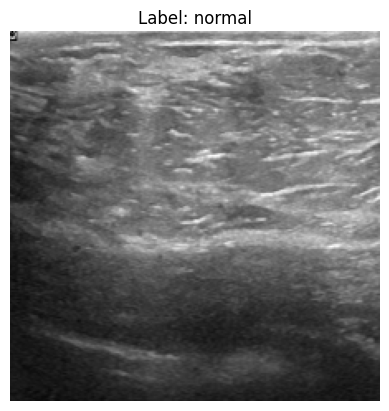

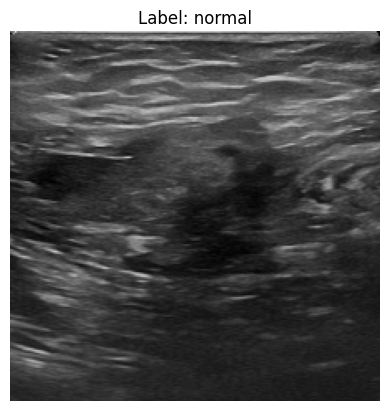

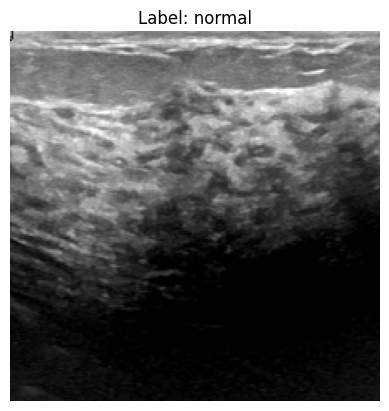

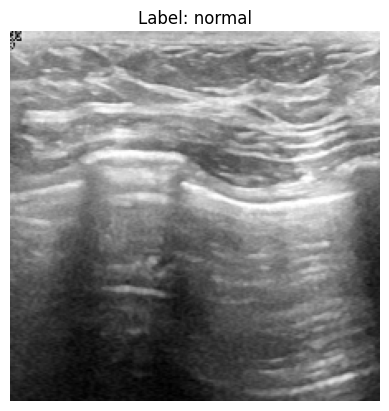

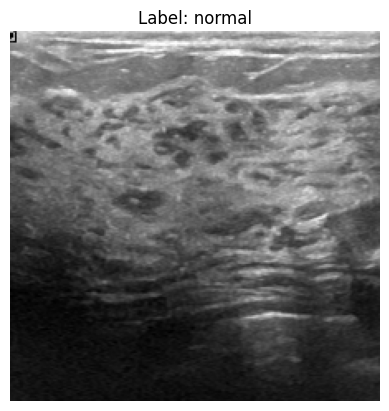

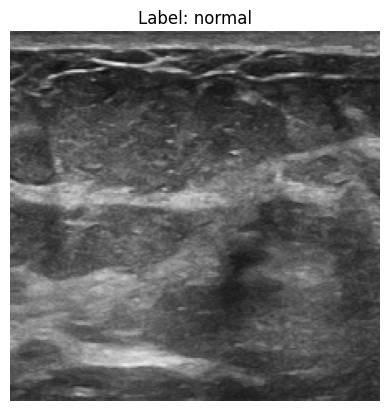

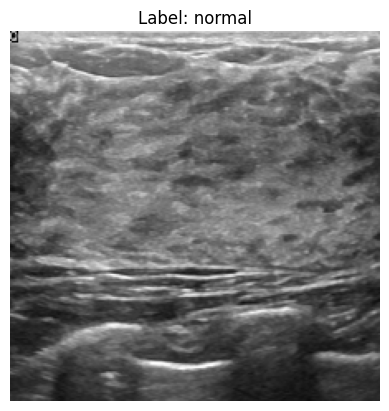

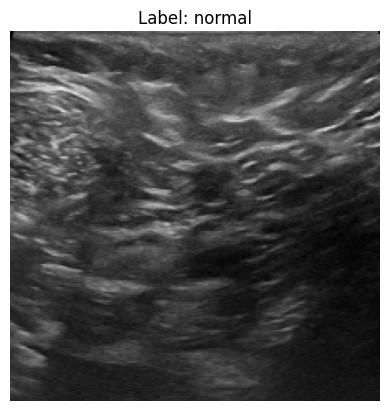

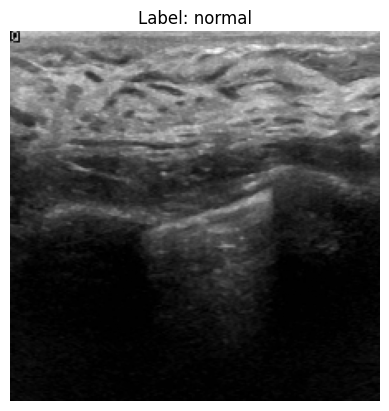

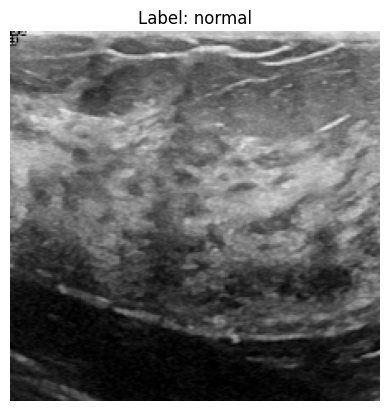

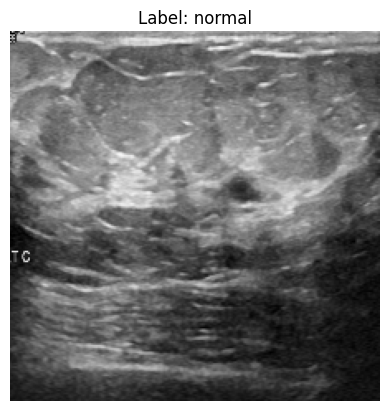

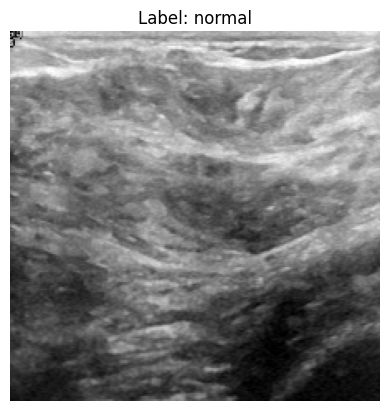

In [15]:
import matplotlib.pyplot as plt

classes = ['normal', 'abnormal']

for i in range(20):
    plt.imshow(X[i])
    plt.title("Label: " + classes[y[i]])
    plt.axis("off")
    plt.show()

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')   # Binary output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.7949 - loss: 0.5592 - val_accuracy: 0.8205 - val_loss: 0.4757
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.8317 - loss: 0.4650 - val_accuracy: 0.8205 - val_loss: 0.4730
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.8317 - loss: 0.4622 - val_accuracy: 0.8205 - val_loss: 0.4495
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.8317 - loss: 0.4437 - val_accuracy: 0.8205 - val_loss: 0.4682
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 77s 4s/step - accuracy: 0.8317 - loss: 0.4298 - val_accuracy: 0.8205 - val_loss: 0.4146
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 76s 4s/step - accuracy: 0.8333 - loss: 0.4117 - val_accuracy: 0.8205 - val_loss: 0.4031
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.8333 - loss: 0.3907 - val_accuracy: 0.8205 - val_loss: 0.3895
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.8333 - loss: 0.4028 - val_accuracy: 0.8205 - val_loss:

In [19]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 757ms/step - accuracy: 0.8205 - loss: 0.3731
Accuracy: 0.8205128312110901


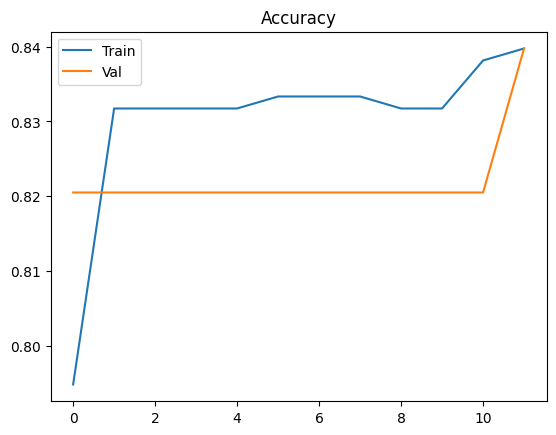

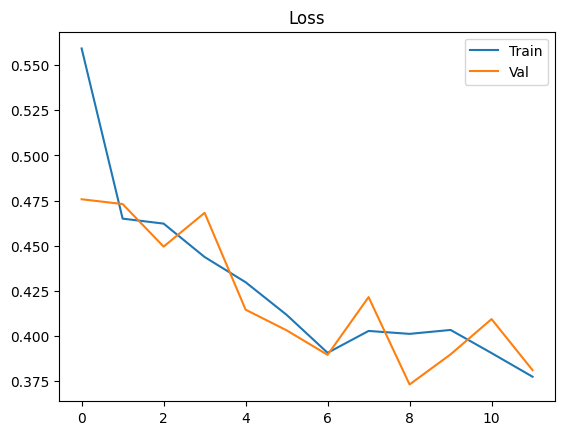

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 782ms/step


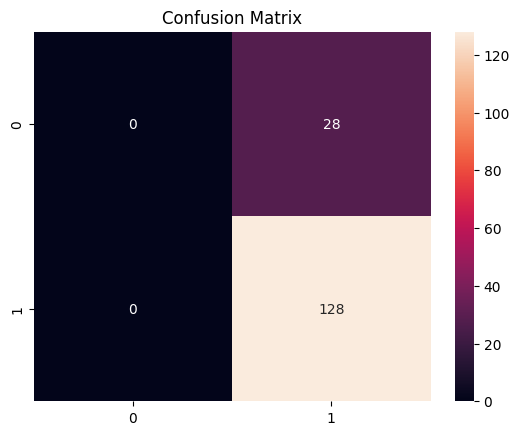

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Prediction: Tumor
True: Tumor


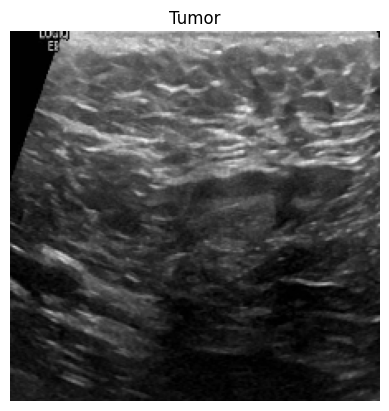

Prediction: Tumor
True: Tumor


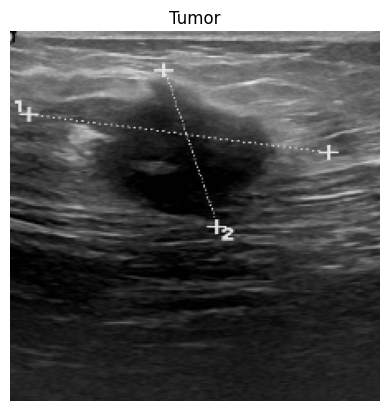

Prediction: Tumor
True: Tumor


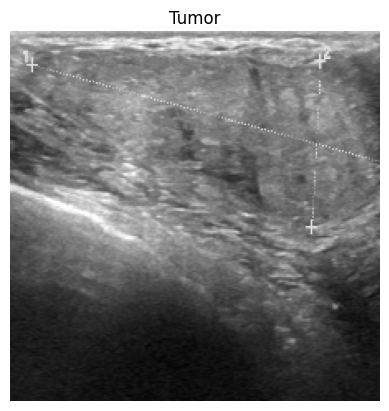

Prediction: Tumor
True: Tumor


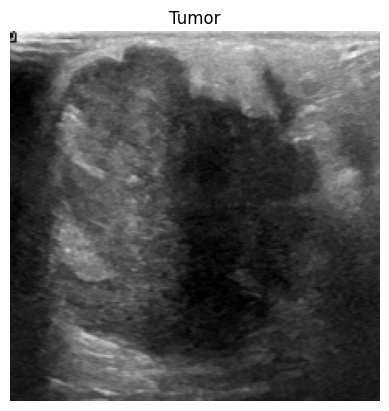

Prediction: Tumor
True: Tumor


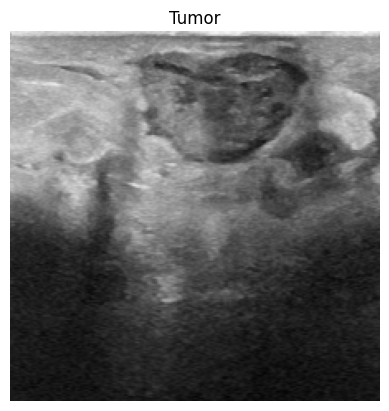

Prediction: Tumor
True: Tumor


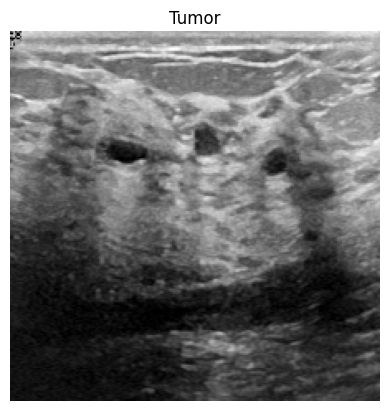

Prediction: Tumor
True: Tumor


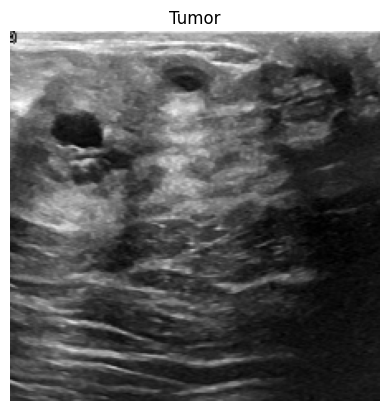

Prediction: Tumor
True: Tumor


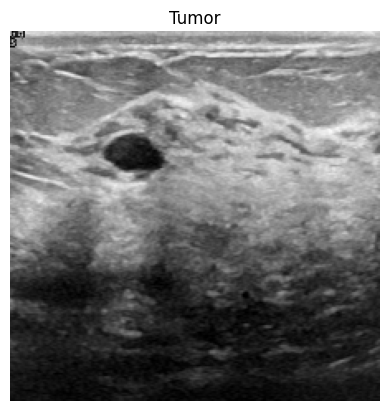

Prediction: Tumor
True: Tumor


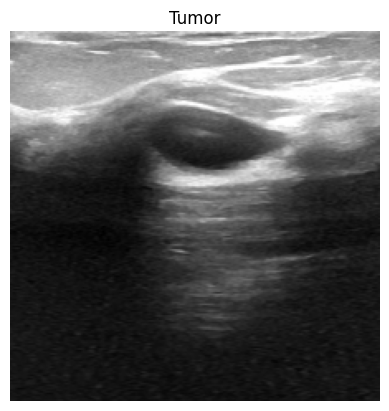

Prediction: Tumor
True: Tumor


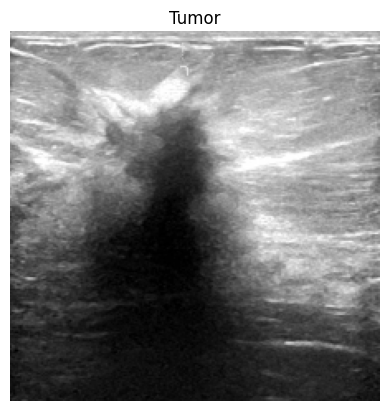

Prediction: Tumor
True: Tumor


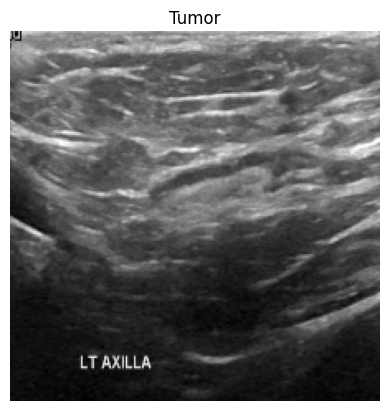

Prediction: Tumor
True: Tumor


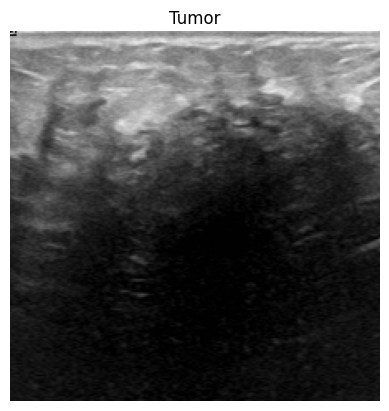

Prediction: Tumor
True: Tumor


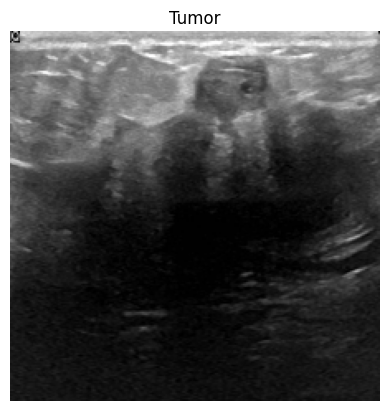

Prediction: Tumor
True: Tumor


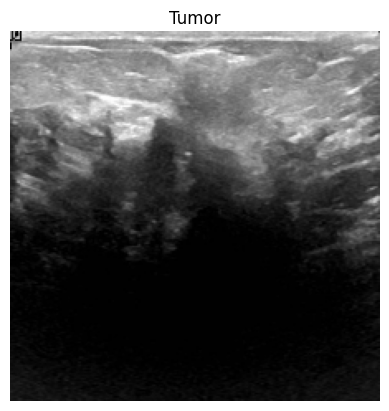

Prediction: Tumor
True: Tumor


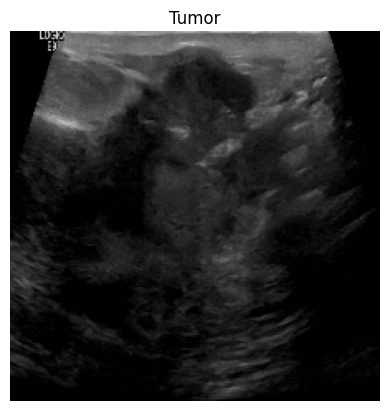

Prediction: Tumor
True: Tumor


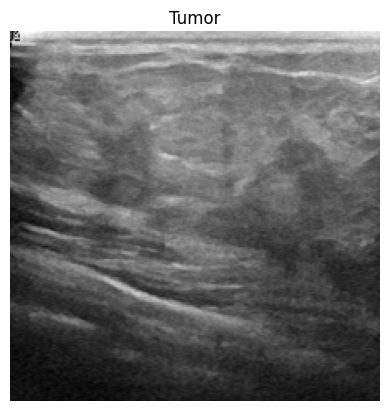

Prediction: Tumor
True: Tumor


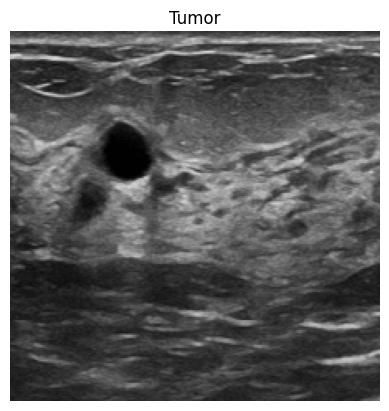

Prediction: Tumor
True: Normal


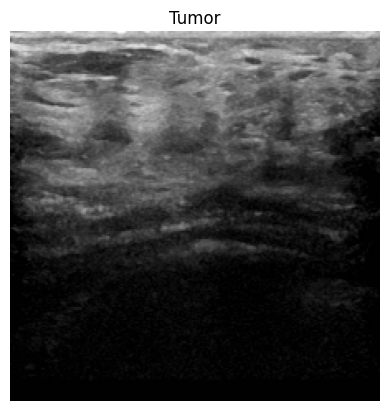

Prediction: Tumor
True: Tumor


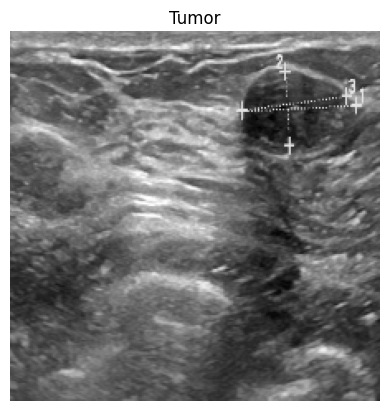

Prediction: Tumor
True: Normal


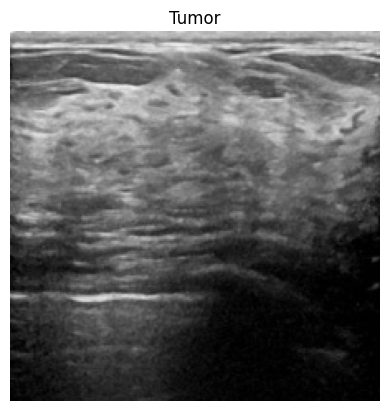

Prediction: Tumor
True: Normal


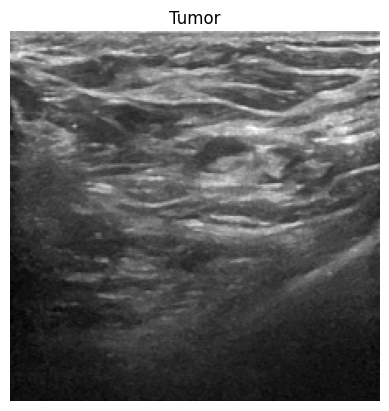

Prediction: Tumor
True: Tumor


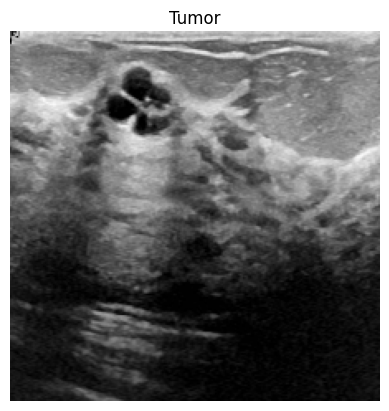

Prediction: Tumor
True: Normal


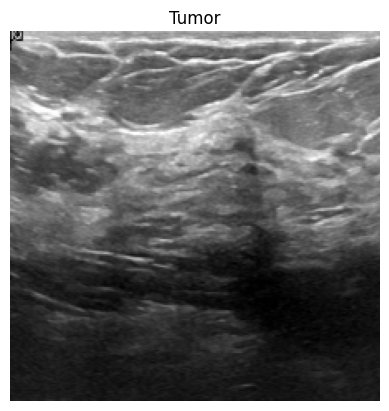

Prediction: Tumor
True: Tumor


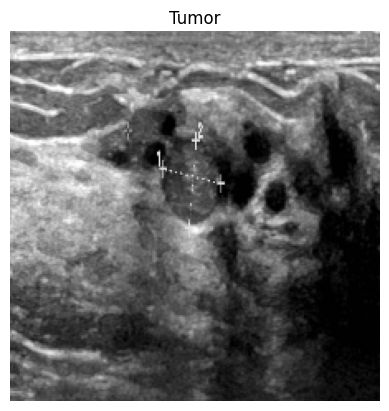

Prediction: Tumor
True: Normal


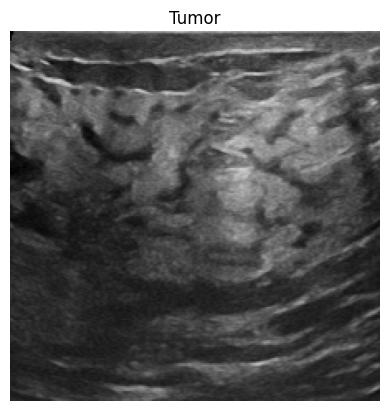

Prediction: Tumor
True: Tumor


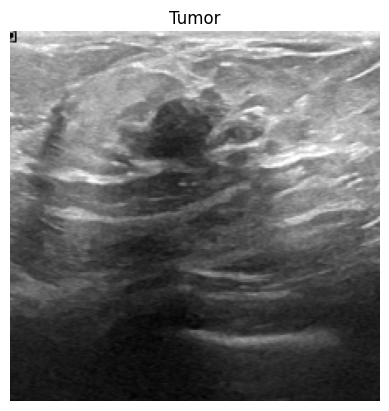

Prediction: Tumor
True: Tumor


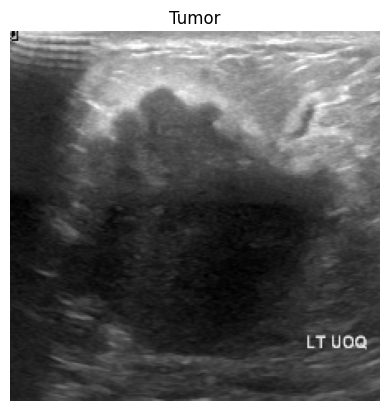

Prediction: Tumor
True: Tumor


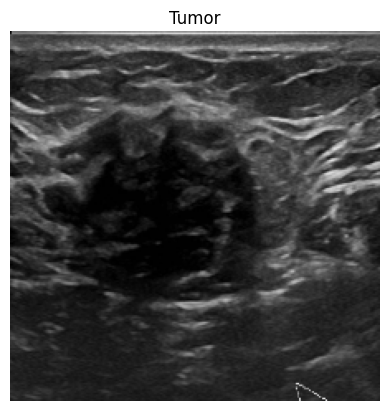

Prediction: Tumor
True: Tumor


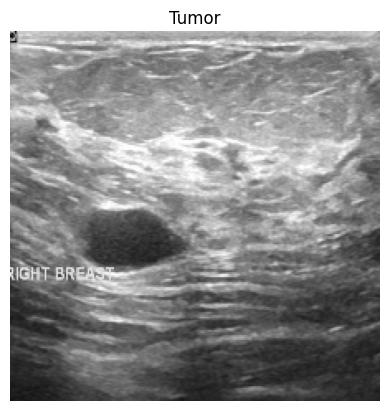

Prediction: Tumor
True: Normal


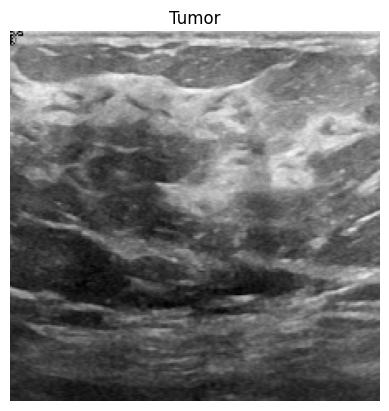

Prediction: Tumor
True: Tumor


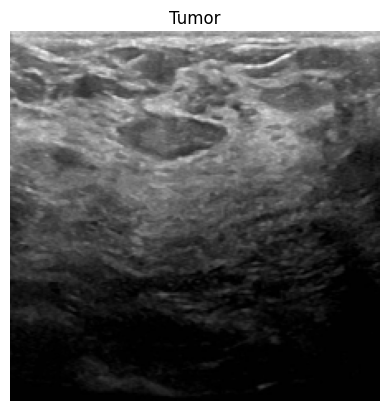

Prediction: Tumor
True: Normal


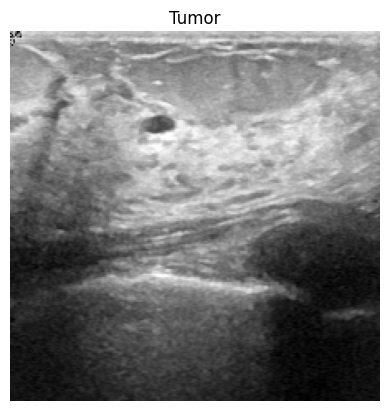

Prediction: Tumor
True: Tumor


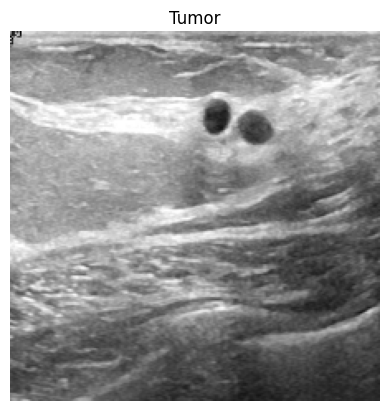

Prediction: Tumor
True: Tumor


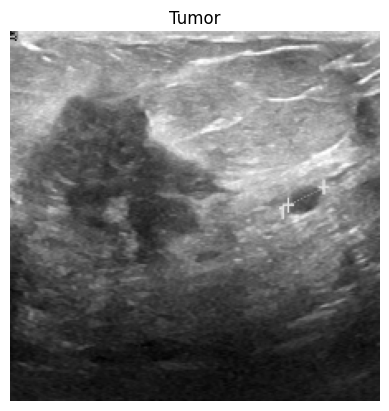

Prediction: Tumor
True: Tumor


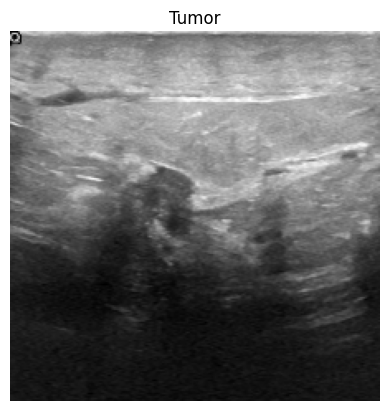

Prediction: Tumor
True: Tumor


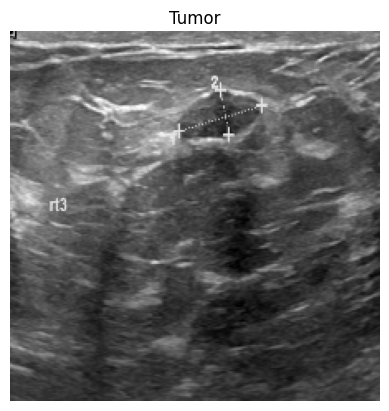

Prediction: Tumor
True: Tumor


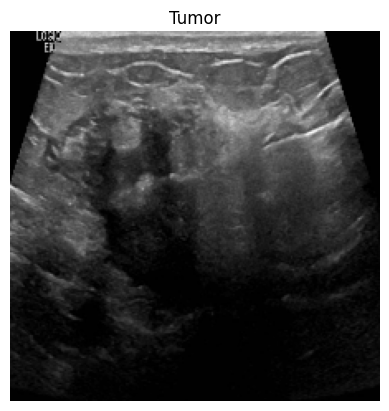

Prediction: Tumor
True: Tumor


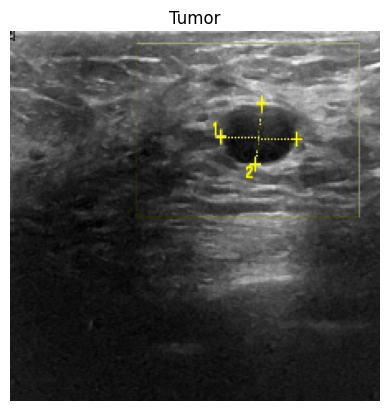

Prediction: Tumor
True: Tumor


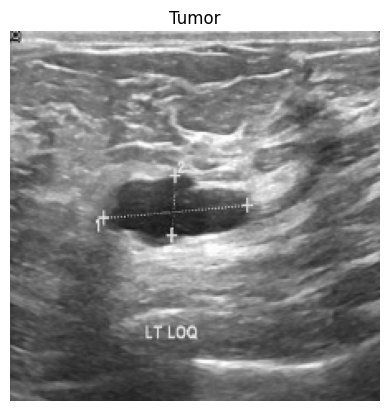

Prediction: Tumor
True: Tumor


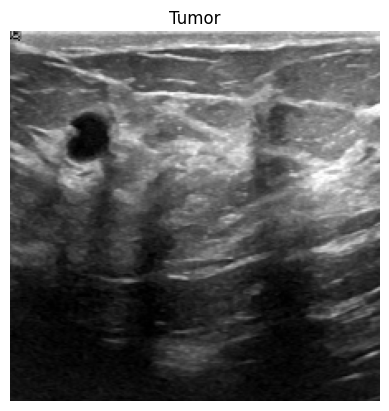

Prediction: Tumor
True: Tumor


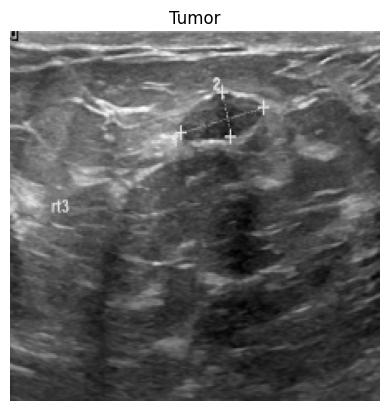

Prediction: Tumor
True: Tumor


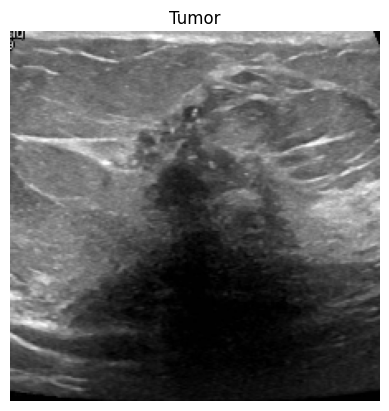

Prediction: Tumor
True: Normal


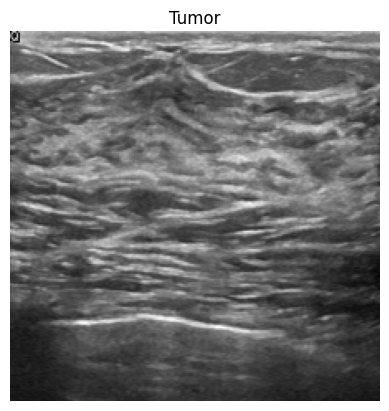

Prediction: Tumor
True: Tumor


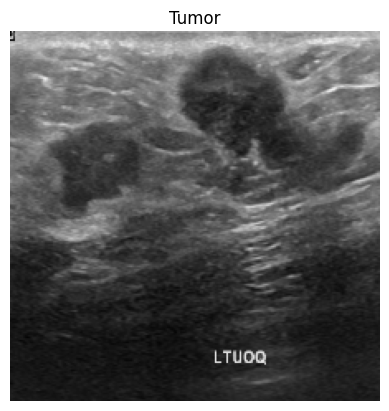

Prediction: Tumor
True: Tumor


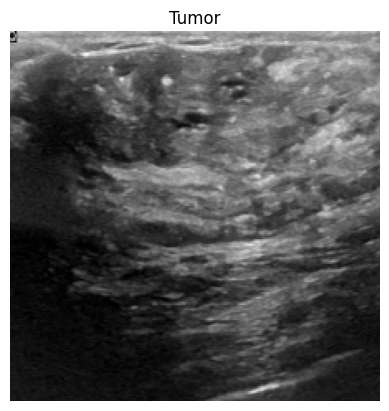

Prediction: Tumor
True: Tumor


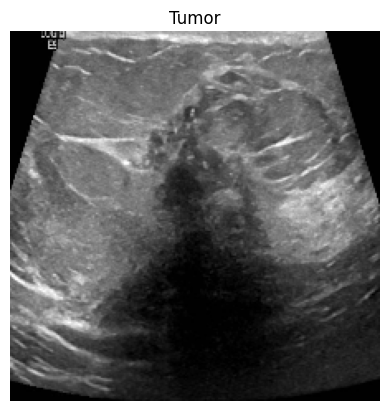

Prediction: Tumor
True: Tumor


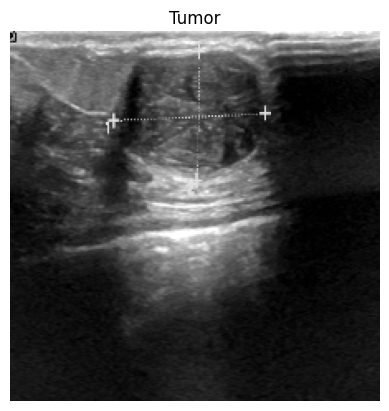

Prediction: Tumor
True: Tumor


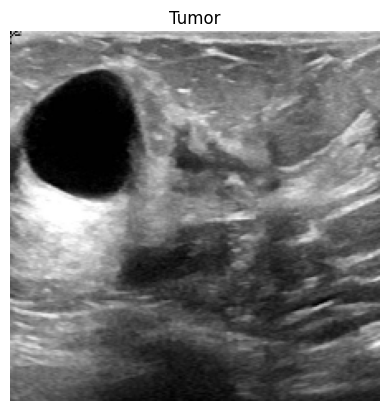

Prediction: Tumor
True: Normal


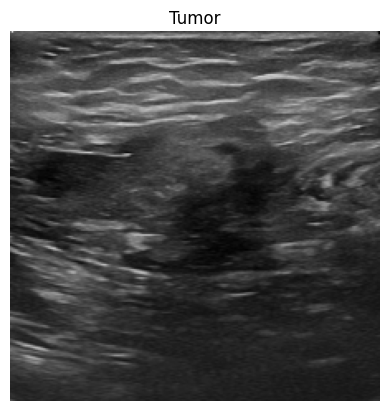

Prediction: Tumor
True: Tumor


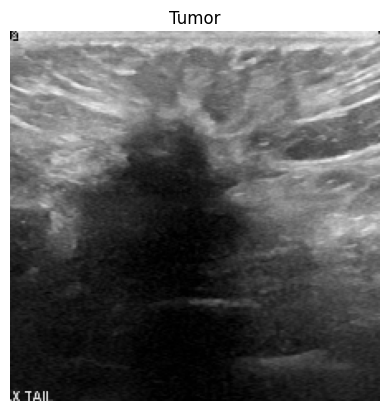

In [24]:
for i in range(min(50, len(X_test))):
    sample = X_test[i].reshape(1, 224, 224, 3)

    pred = model.predict(sample, verbose=0).flatten()[0]

    label = "Tumor" if pred > 0.5 else "Normal"

    print("Prediction:", label)
    print("True:", "Tumor" if y_test[i] == 1 else "Normal")

    # Convert the image back to uint8 before passing to cv2.cvtColor
    display_image = (X_test[i] * 255).astype(np.uint8)
    plt.imshow(cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis("off")
    plt.show()

In [25]:
model.save("cnn_model_binary.keras")

In [26]:
from google.colab import files
files.download("cnn_model_binary.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pyngrok

In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
from flask import Flask, request, jsonify
import tensorflow as tf
import numpy as np
import cv2
from pyngrok import ngrok

ngrok.set_auth_token("3C8G5fSSxJXV5aN9EoZIDm3kTvP_7hmrsfzdiCAtgt36PoBSW")

app = Flask(__name__)

model = tf.keras.models.load_model("model_tf.keras", compile=False)
classes = ["normal", "benign", "malignant"]

@app.route("/")
def home():
    return "API is working 🔥"

@app.route("/predict", methods=["POST"])
def predict():
    file = request.files["image"]

    img = cv2.imdecode(np.frombuffer(file.read(), np.uint8), cv2.IMREAD_COLOR)
    img = cv2.resize(img, (224, 224)) / 255.0
    img = np.reshape(img, (1, 224, 224, 3))

    pred = model.predict(img)
    result = classes[np.argmax(pred)]

    return jsonify({"prediction": result})

public_url = ngrok.connect(addr=5000)
print("Public URL:", public_url)

app.run()

Public URL: NgrokTunnel: "https://boasting-penny-heroism.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [09/Apr/2026 19:58:26] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [09/Apr/2026 19:58:27] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [09/Apr/2026 19:58:49] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [09/Apr/2026 20:02:59] "GET /predict HTTP/1.1" 405 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


INFO:werkzeug:127.0.0.1 - - [09/Apr/2026 20:04:46] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [09/Apr/2026 20:07:51] "GET / HTTP/1.1" 200 -
